# Hyperparameter Search Analysis

Generator: `gpt-5.4-nano` · Evaluator: `gpt-5.4-mini` · Cases: `pl_age`, `pl_personal_rights`

| Parameter | Abbrev. | Values |
|---|---|---|
| `max_refinement_rounds` | `maxrr` | 2, 3, 4 |
| `min_refinement_rounds` | `minrr` | 1, 2 |
| `max_data_refinement_rounds` | `maxdrr` | 2, 3, 4 |
| `min_data_refinement_rounds` | `mindrr` | 1, 2 |
| `data_assessment_num_examples` | `dane` | 1, 2, 3 |

In [19]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

%matplotlib inline

EVAL_DIR = Path("outputs/evaluation/gpt-5.4-mini/gpt-5.4-nano")
FIGURES_DIR = Path("outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PARAMS = ["minrr", "maxrr", "mindrr", "maxdrr", "dane"]
PARAM_LABELS = {
    "maxrr": "Max refinement rounds",
    "minrr": "Min refinement rounds",
    "maxdrr": "Max data refinement rounds",
    "mindrr": "Min data refinement rounds",
    "dane": "Data assessment examples",
}
CASES = ["pl_age", "pl_personal_rights"]
PARAM_RE = re.compile(r"maxrr_(\d+)_minrr_(\d+)_maxdrr_(\d+)_mindrr_(\d+)_dane_(\d+)")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [20]:
records = []
for path in sorted(EVAL_DIR.glob("**/evaluation.json")):
    m = PARAM_RE.match(path.parent.name)
    if not m:
        continue
    params = dict(zip(PARAMS, map(int, m.groups())))
    ed = json.loads(path.read_text())
    cov, hc = [], []
    for schema in ed["evaluations"]:
        for expert in schema["experts"]:
            t = expert["total_questions"]
            if t:
                cov.append(expert["covered_questions"] / t)
                hc.append(expert["high_confidence"] / t)
    records.append({
        "case": path.parent.parent.name,
        **params,
        "coverage_rate": float(np.mean(cov)),
        "high_conf_rate": float(np.mean(hc)),
    })

df = pd.DataFrame(records)
print(f"{len(df)} runs · {df['case'].nunique()} cases · {df[PARAMS].drop_duplicates().shape[0]} unique configs")

216 runs · 2 cases · 108 unique configs


## Best parameter set

In [21]:
ranked = (
    df.groupby(PARAMS)[["coverage_rate", "high_conf_rate"]]
    .mean()
    .reset_index()
    .sort_values(["coverage_rate", "high_conf_rate"], ascending=False)
    .reset_index(drop=True)
)
ranked.index += 1

display(ranked.head(10).style
    .format({"coverage_rate": "{:.3f}", "high_conf_rate": "{:.3f}"})
    .highlight_max(subset=["coverage_rate", "high_conf_rate"], color="#c6efce")
)

best = ranked.iloc[0]
print("\nBest configuration:")
for p in PARAMS:
    print(f"  {p} = {int(best[p])}")
print(f"  coverage_rate  = {best['coverage_rate']:.4f}")
print(f"  high_conf_rate = {best['high_conf_rate']:.4f}")

,minrr,maxrr,mindrr,maxdrr,dane,coverage_rate,high_conf_rate
1,4,1,3,1,2,0.879,0.798
2,3,2,3,1,3,0.877,0.744
3,3,1,3,2,3,0.877,0.744
4,3,2,3,2,3,0.877,0.744
5,2,1,3,1,3,0.872,0.753
6,2,2,3,2,3,0.872,0.753
7,2,1,3,2,3,0.872,0.753
8,3,1,3,1,3,0.870,0.783
9,2,2,3,1,3,0.866,0.781
10,4,2,2,1,1,0.851,0.738



Best configuration:
  minrr = 4
  maxrr = 1
  mindrr = 3
  maxdrr = 1
  dane = 2
  coverage_rate  = 0.8789
  high_conf_rate = 0.7983


## Parameter influence on coverage rate

Saved: outputs/figures/param_influence_coverage.pdf


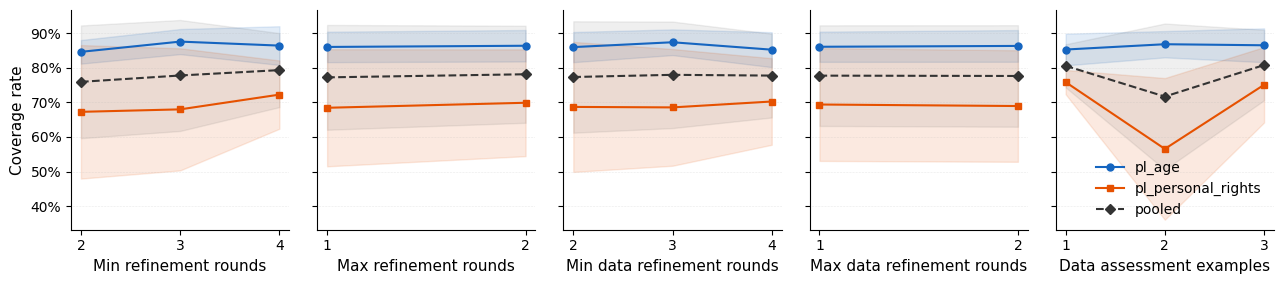


Marginal effect (pooled, range of means):
  minrr    Δ=0.0339 (3.4 pp)
  maxrr    Δ=0.0090 (0.9 pp)
  mindrr   Δ=0.0063 (0.6 pp)
  maxdrr   Δ=0.0010 (0.1 pp)
  dane     Δ=0.0910 (9.1 pp)


In [22]:
COLORS = {"pl_age": "#1565C0", "pl_personal_rights": "#E65100", "pooled": "#333333"}
MARKERS = {"pl_age": "o", "pl_personal_rights": "s", "pooled": "D"}
LABELS = {"pl_age": "pl_age", "pl_personal_rights": "pl_personal_rights", "pooled": "pooled"}

fig, axes = plt.subplots(1, 5, figsize=(13, 3.0), sharey=True)

for ax, param in zip(axes, PARAMS):
    for case in CASES:
        sub = df[df["case"] == case]
        s = sub.groupby(param)["coverage_rate"].agg(["mean", "std"]).reset_index()
        ax.plot(s[param], s["mean"], marker=MARKERS[case], color=COLORS[case],
                linewidth=1.5, markersize=5, label=LABELS[case])
        ax.fill_between(s[param], s["mean"] - s["std"].fillna(0),
                        s["mean"] + s["std"].fillna(0), color=COLORS[case], alpha=0.12)

    s_pool = df.groupby(param)["coverage_rate"].agg(["mean", "std"]).reset_index()
    ax.plot(s_pool[param], s_pool["mean"], marker=MARKERS["pooled"], color=COLORS["pooled"],
            linewidth=1.5, markersize=5, linestyle="--", label=LABELS["pooled"])
    ax.fill_between(s_pool[param], s_pool["mean"] - s_pool["std"].fillna(0),
                    s_pool["mean"] + s_pool["std"].fillna(0), color=COLORS["pooled"], alpha=0.08)

    ax.set_xlabel(PARAM_LABELS[param])
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.grid(axis="y", linewidth=0.4, linestyle=":", alpha=0.5)

axes[0].set_ylabel("Coverage rate")
axes[-1].legend(loc="lower right", frameon=False)
fig.tight_layout()

out = FIGURES_DIR / "param_influence_coverage.pdf"
fig.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

print("\nMarginal effect (pooled, range of means):")
for param in PARAMS:
    means = df.groupby(param)["coverage_rate"].mean()
    delta = means.max() - means.min()
    print(f"  {param:<8} Δ={delta:.4f} ({delta*100:.1f} pp)")